In [2]:
from src.data import DATA_DIR_INTERIM, DATA_DIR_PROCESSED
from src.io import load_qrel_from_path, read_metadata
from src.config import MODEL_SORTER, PROMPT_SORTER
from topic_gen.evaluate.io import load_from_irds
from topic_gen.evaluate import MetaExperiment
from topic_gen.evaluate.measures_agreement import CohenKappa, MeanAverageError
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

/Users/jueri/projects/sigir26-generating-topics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATASETS = {
    "robust": {
        "binary": "label-alignment-robust-qrels-topics-generated-binary.tsv",
        "graded": "label-alignment-robust-qrels-topics-generated.tsv",
        "irds": "disks45/nocr/trec-robust-2004",
        "results_dir": "qrels-topics-generated",
    },
    "dl19": {
        "binary": "label-alignment-dl19-qrels-topics-generated-full-binary.tsv",
        "graded": "label-alignment-dl19-qrels-topics-generated-full.tsv",
        "irds": "msmarco-passage/trec-dl-2019/judged",
        "results_dir": "qrels-topics-generated-full",
    },
    "dl20": {
        "binary": "label-alignment-dl20-qrels-topics-generated-full-binary.tsv",
        "graded": "label-alignment-dl20-qrels-topics-generated-full.tsv",
        "irds": "msmarco-passage/trec-dl-2020/judged",
        "results_dir": "qrels-topics-generated-full",
    },
}

In [ ]:

def load_results(dataset: str) -> pd.DataFrame:
    # load metadata
    metadata = read_metadata(
        DATA_DIR_INTERIM / dataset / DATASETS[dataset]["results_dir"]
    )
    metadata = metadata.fillna(0)
    metadata.replace({"GPT-OSS-120B-O": "gpt-oss-120b", "GPT-OSS-120B": "gpt-oss-120b", "GPT-OSS-20B": "gpt-oss-20b", "Qwen3-Next-80B": "Qwen3-Next"}, inplace=True)

    metadata["topics_model"].fillna("TREC", inplace=True)

    metadata = metadata[
        (metadata["topics_nqueries"] <= 1.0)
        & (metadata["topics_prompt"] != "human")
    ]

    metadata["model"] = pd.Categorical(metadata["model"], ["gpt-oss-120b", "gpt-oss-20b", "Qwen3-Next", "Qwen3-30B"])
    metadata["topics_prompt"] = pd.Categorical(metadata["topics_prompt"], PROMPT_SORTER)
    metadata["topics_prompt"] = metadata["topics_prompt"].cat.remove_unused_categories()

    metadata["display_name"] = metadata.apply(
        lambda row: f"{row['topics_prompt']}-{int(float(row['topics_nqueries']))}-{int(float(row['topics_ndocspos']))}-{int(float(row['topics_ndocsneg']))}",
        axis=1,
    )

    # load results
    df = pd.read_csv(DATA_DIR_PROCESSED / DATASETS[dataset]["graded"], sep="\t")
    df = df.replace("Cohens $\kappa$", "kappa")
    df = df.drop_duplicates()
    df = df.pivot(index="name", columns="measure", values="value").reset_index()

    df = metadata.merge(df[["name", "kappa", "MAE"]], left_on="name", right_on="name")
    df["kappa"] = df["kappa"].apply(pd.to_numeric, errors="coerce")
    df["display_name"] = df["topics_prompt"].str.replace("topic-", "")

    ordered_display_names = df.sort_values("topics_prompt")["display_name"].unique()

    df["display_name"] = pd.Categorical(df["display_name"], categories=ordered_display_names, ordered=True)

    df["context"] = df[["topics_nqueries", "topics_ndocspos", "topics_ndocsneg"]].max(axis=1)
    
    
    # same LLM
    df['is_same_model'] = (df['model'] == df['topics_model']).astype(int)

    # same family
    df['judge_family'] = df['model'].str.split('-').str[0]
    df['topic_family'] = df['topics_model'].str.split('-').str[0]
    df['is_same_family'] = (df['judge_family'] == df['topic_family']).astype(int)

    # Total context size (sum of pos and neg docs)
    df['total_docs'] = df['topics_ndocspos'] + df['topics_ndocsneg']
    
    # filter out other prompts
    valid_prompts = [
    'topic-query', 
    'topic-query-contrastive', 
    'topic-query-docs-neg', 
    'topic-query-docs-pos'
]

    df = df[df['topics_prompt'].isin(valid_prompts)]
    
    # remove unused categories
    df["topics_prompt"] = df["topics_prompt"].cat.remove_unused_categories()

    return df

<>:27: SyntaxWarning: invalid escape sequence '\k'
<>:27: SyntaxWarning: invalid escape sequence '\k'
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/1808734156.py:27: SyntaxWarning: invalid escape sequence '\k'
  df = df.replace("Cohens $\kappa$", "kappa")


In [5]:
def full_plot(df: pd.DataFrame):
    fig, axes = plt.subplots(4, 5, figsize=(18, 15))
    axes_flat = axes.flatten()

    df = df[df["topics_prompt"] != "topic-query"]
    groups = df.groupby(by=["prompt", "topics_prompt",
                        "topics_nqueries", "topics_ndocsneg", "topics_ndocspos"])

    for ax, (key, df) in zip(axes_flat, groups):
        df = df.copy()

        row = df.iloc[0]
        name = row["topics_prompt"] + \
            "-" + str(int(row["topics_nqueries"])) + \
            "-" + str(int(row["topics_ndocsneg"])) + \
            "-" + str(int(row["topics_ndocspos"]))

        # df["CohenKappa"] = df["CohenKappa"].apply(
        #     lambda x: float(str(x).split(" ± ")[0]))
        df["model"] = df["model"].str.replace("no-think", "")
        df["topics_model"] = df["topics_model"].str.replace("no-think", "")
        df_pivot = df[["name", "kappa", "model", "topics_model"]].pivot(
            index="model",
            columns="topics_model",
            values="kappa"
        )

        sns.heatmap(df_pivot,
                    annot=True,
                    cmap='YlGnBu',
                    ax=ax,
                    vmin=0.0,
                    vmax=0.5
                    )
        # rotate x labels
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        
        ax.set_xlabel('Topic LLM')
        ax.set_ylabel('Qrel LLM')
        ax.set_title(name)

    if len(groups) < len(axes_flat):
        for i in range(len(groups), len(axes_flat)):
            fig.delaxes(axes_flat[i])

    plt.tight_layout()
    plt.show()
    

# DL19

/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/1808734156.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata = metadata.fillna(0)
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/1808734156.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  metadata["topics_model"].f

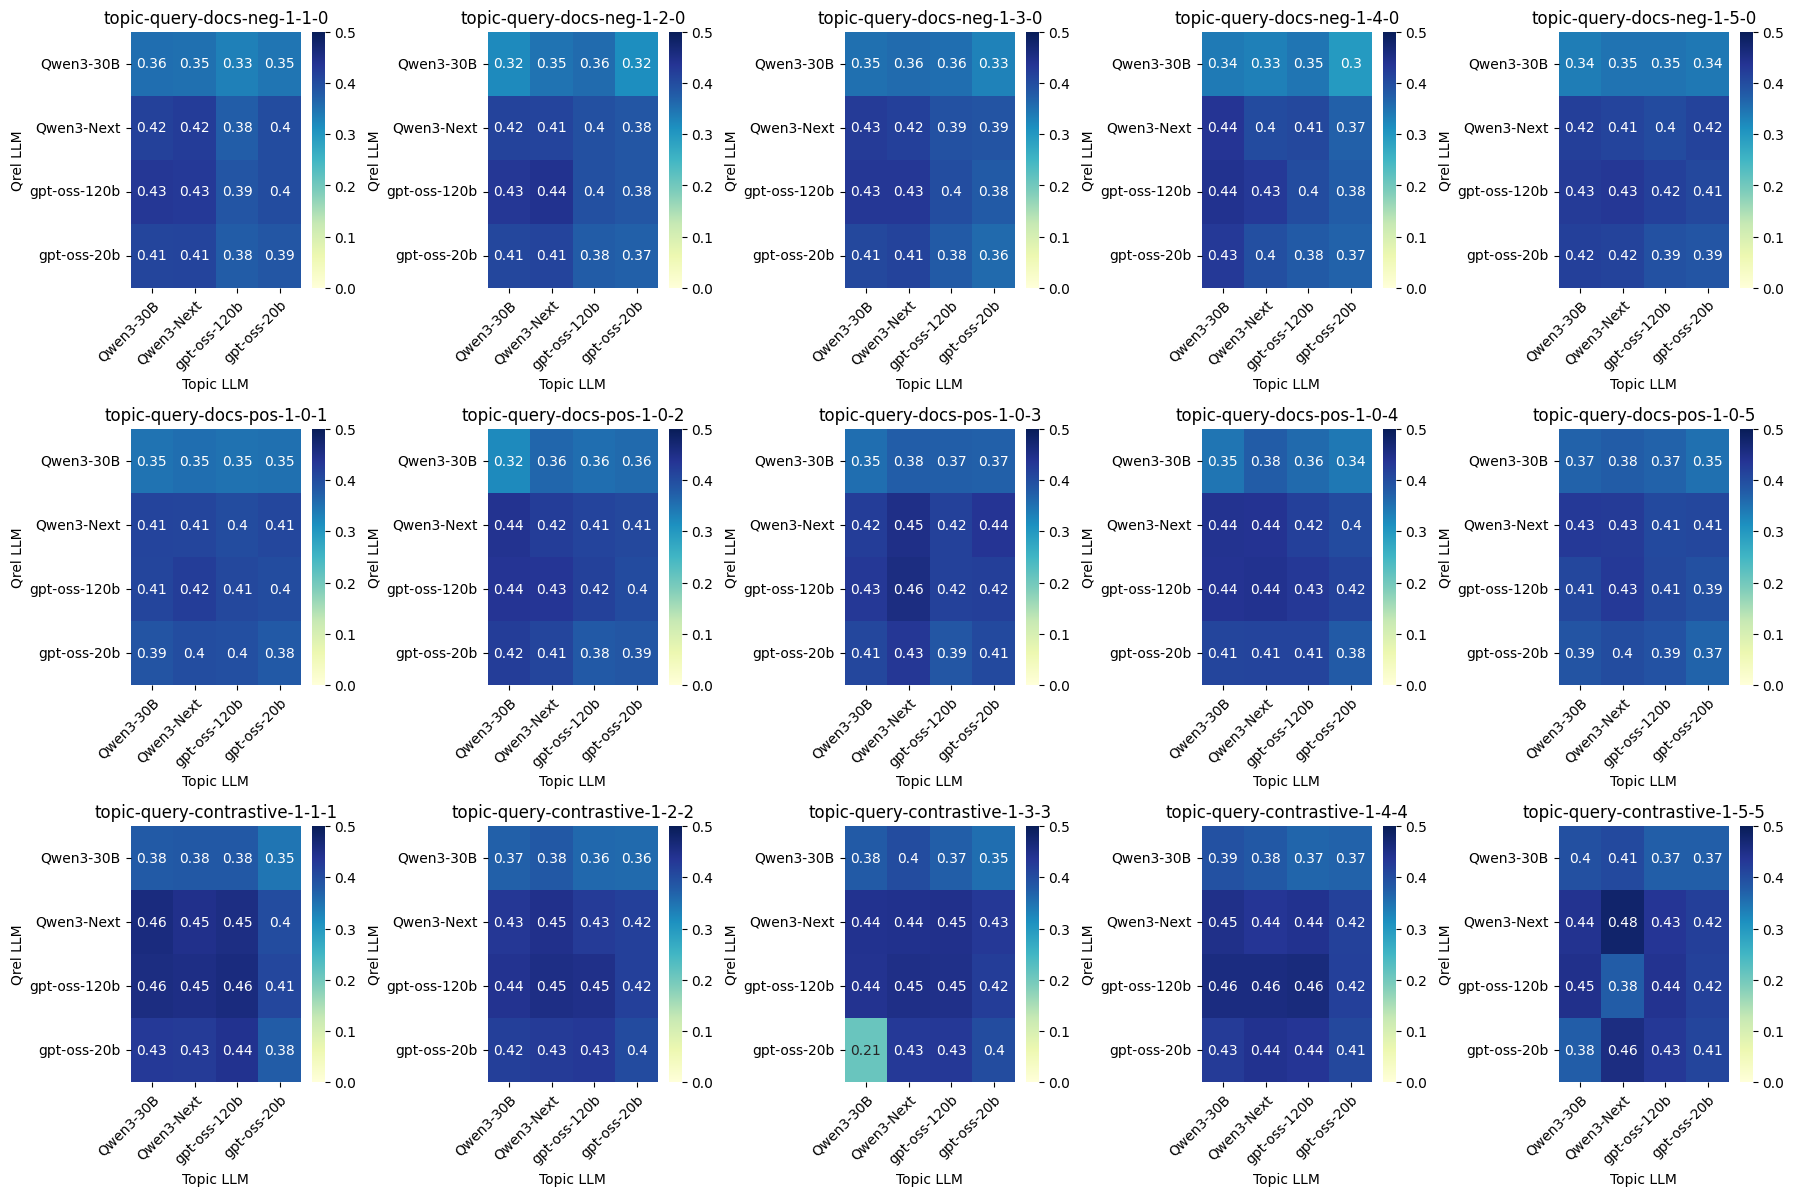

In [27]:
df = load_results("dl19")
full_plot(df)

/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/2722070942.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(df.pivot_table(index="model", columns="topics_model", values="kappa", aggfunc="mean"),annot=True, vmax=0.5, vmin=0.0,  cbar_kws={"label": "Cohen's Kappa"})


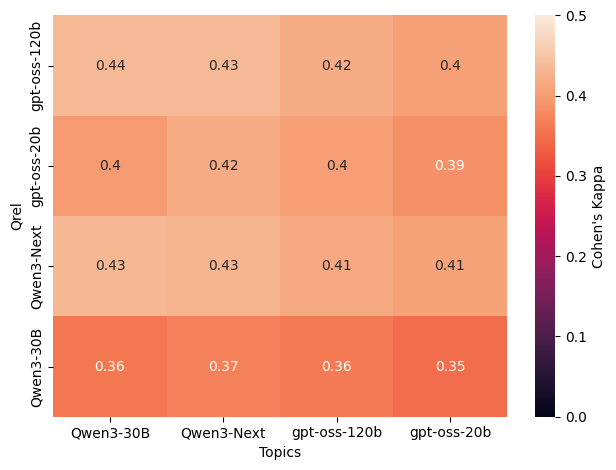

In [28]:
sns.heatmap(df.pivot_table(index="model", columns="topics_model", values="kappa", aggfunc="mean"),annot=True, vmax=0.5, vmin=0.0,  cbar_kws={"label": "Cohen's Kappa"})
plt.xlabel("Topics")
plt.ylabel("Qrel")

plt.tight_layout()
plt.show()

In [31]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# formula = 'kappa ~ C(is_same_model) + C(is_same_family) + C(topics_prompt) + topics_ndocspos + topics_ndocsneg'
formula = "kappa ~ is_same_model + total_docs + C(model) + C(topics_model) + C(topics_prompt)"
model = smf.ols(formula, data=df).fit()

print(model.summary())
anova_table = sm.stats.anova_lm(model, typ=2)

# Eta Squared
anova_table['eta_sq'] = anova_table['sum_sq'] / sum(anova_table['sum_sq'])

print(anova_table)

                            OLS Regression Results                            
Dep. Variable:                  kappa   R-squared:                       0.713
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     55.04
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           9.19e-60
Time:                        17:47:06   Log-Likelihood:                 647.94
No. Observations:                 256   AIC:                            -1272.
Df Residuals:                     244   BIC:                            -1229.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

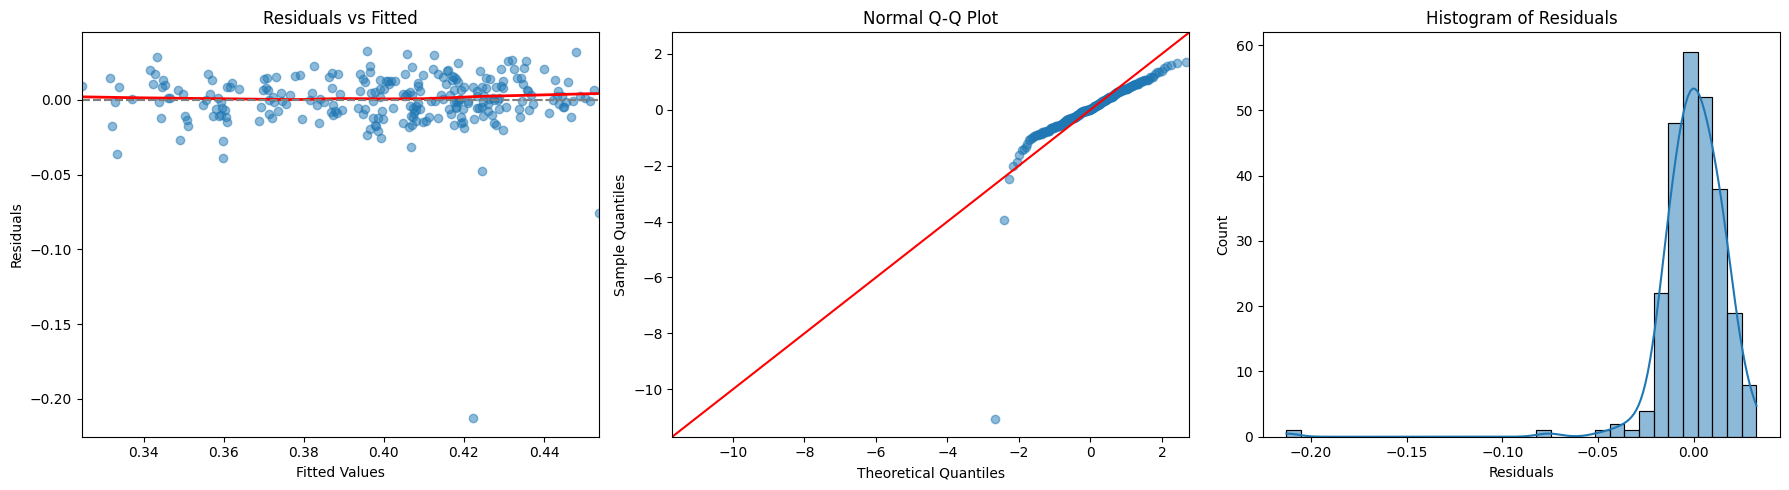

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

fitted_vals = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Residuals vs. Fitted (Checks for Homoscedasticity)
sns.residplot(x=fitted_vals, y=residuals, lowess=True, 
              scatter_kws={'alpha': 0.5}, 
              line_kws={'color': 'red', 'lw': 2}, ax=axes[0])
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].axhline(0, color='grey', linestyle='dashed')

# Plot B: Normal Q-Q Plot (Checks for Normality)
sm.qqplot(residuals, fit=True, line='45', ax=axes[1], alpha=0.5)
axes[1].set_title('Normal Q-Q Plot')

# Plot C: Histogram of Residuals (Visualizes Skew/Kurtosis)
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title('Histogram of Residuals')
axes[2].set_xlabel('Residuals')

plt.tight_layout()
plt.show()

# DL 20

/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/1808734156.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata = metadata.fillna(0)
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/1808734156.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  metadata["topics_model"].f

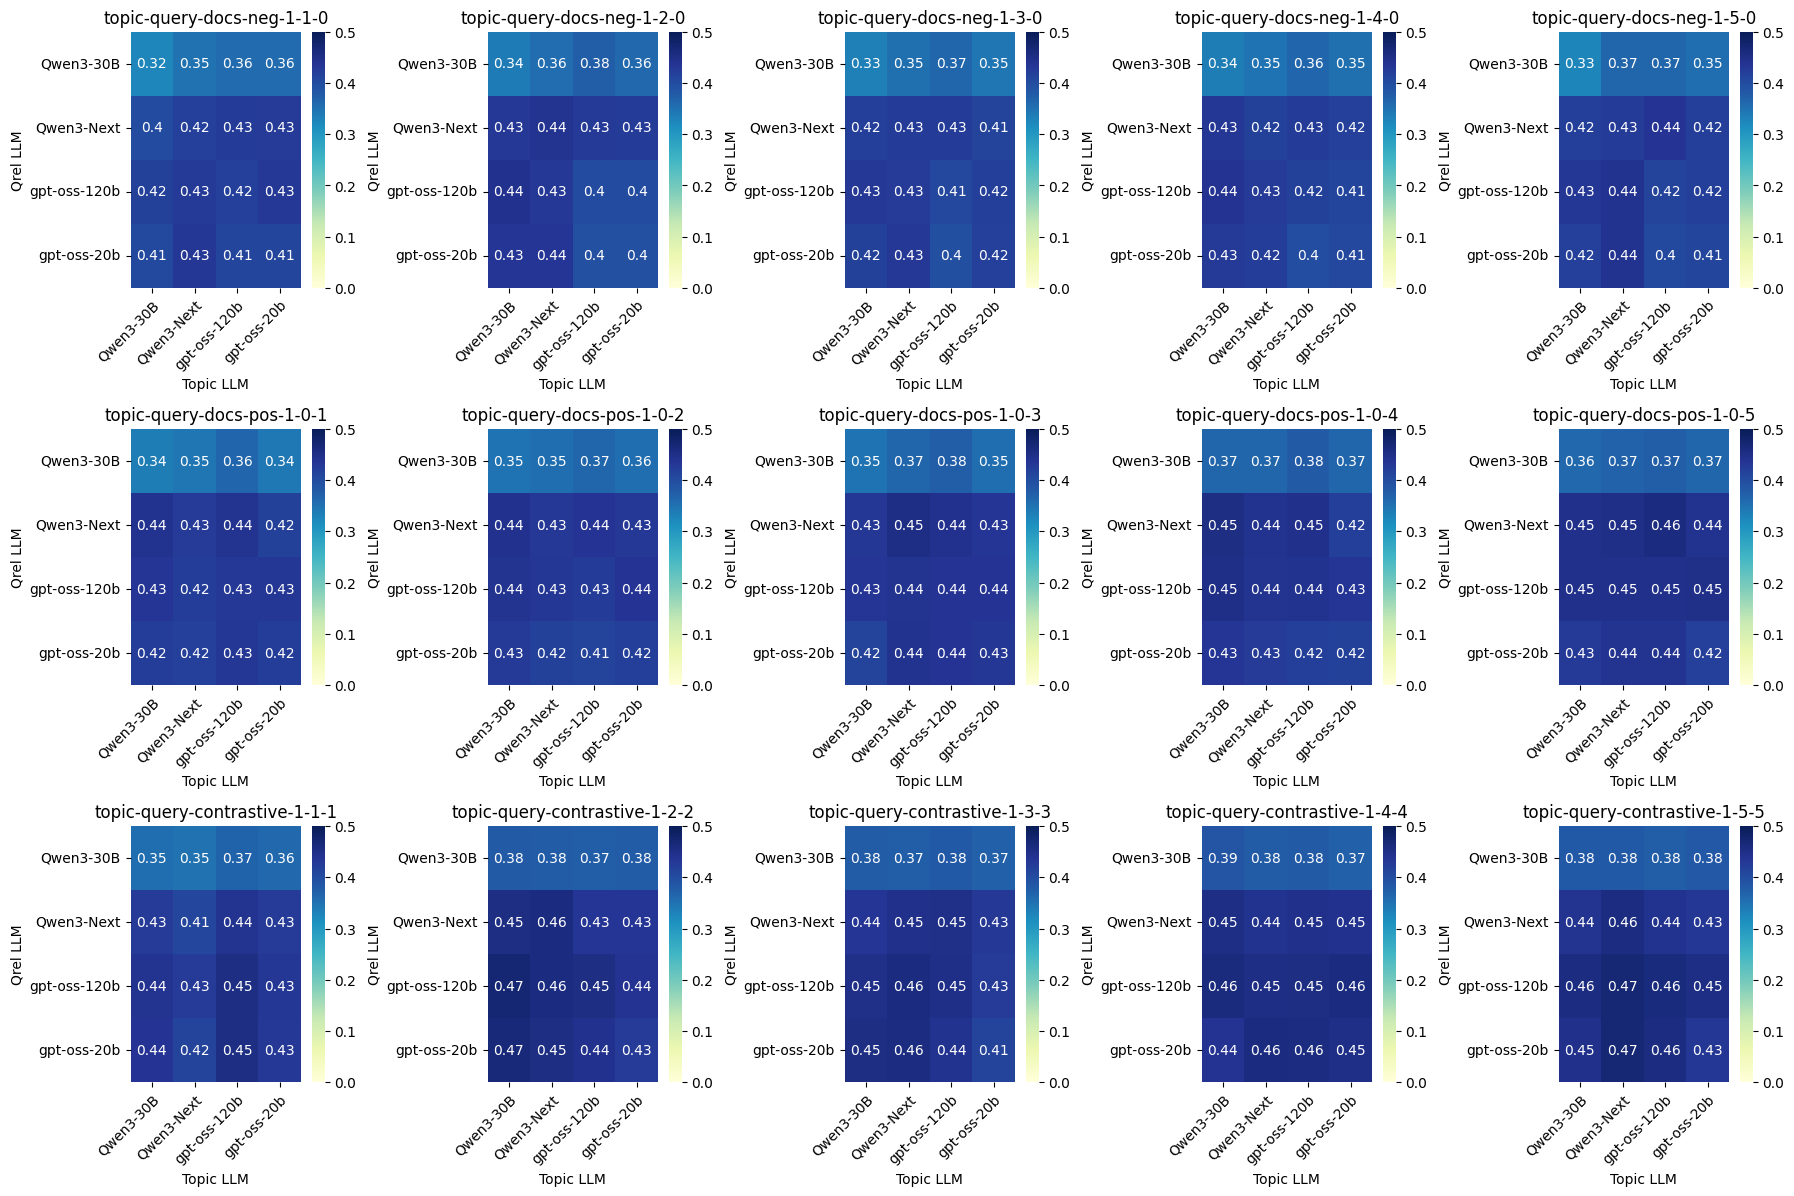

In [33]:
df = load_results("dl20")
full_plot(df)

/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/2722070942.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(df.pivot_table(index="model", columns="topics_model", values="kappa", aggfunc="mean"),annot=True, vmax=0.5, vmin=0.0,  cbar_kws={"label": "Cohen's Kappa"})


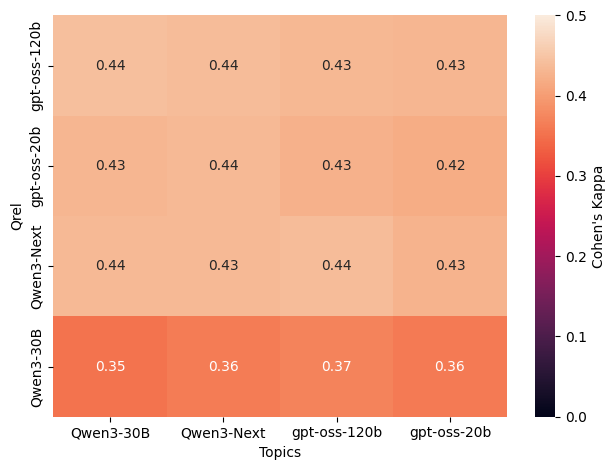

In [34]:
sns.heatmap(df.pivot_table(index="model", columns="topics_model", values="kappa", aggfunc="mean"),annot=True, vmax=0.5, vmin=0.0,  cbar_kws={"label": "Cohen's Kappa"})
plt.xlabel("Topics")
plt.ylabel("Qrel")

plt.tight_layout()
plt.show()

In [35]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# formula = 'kappa ~ C(is_same_model) + C(is_same_family) + C(topics_prompt) + topics_ndocspos + topics_ndocsneg'
formula = "kappa ~ is_same_model + total_docs + C(model) + C(topics_model) + C(topics_prompt)"
model = smf.ols(formula, data=df).fit()

print(model.summary())
anova_table = sm.stats.anova_lm(model, typ=2)

# Eta Squared
anova_table['eta_sq'] = anova_table['sum_sq'] / sum(anova_table['sum_sq'])

print(anova_table)

                            OLS Regression Results                            
Dep. Variable:                  kappa   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     245.0
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          4.94e-125
Time:                        17:47:16   Log-Likelihood:                 816.49
No. Observations:                 256   AIC:                            -1609.
Df Residuals:                     244   BIC:                            -1566.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

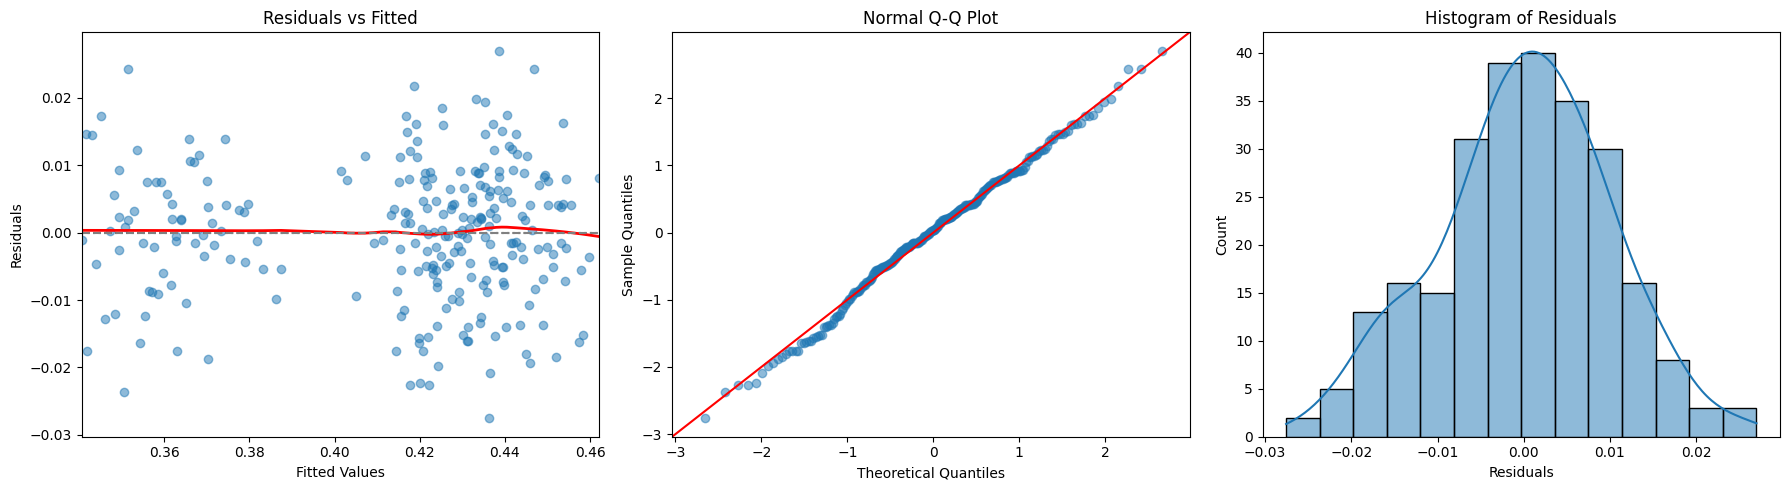

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

fitted_vals = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Residuals vs. Fitted (Checks for Homoscedasticity)
sns.residplot(x=fitted_vals, y=residuals, lowess=True, 
              scatter_kws={'alpha': 0.5}, 
              line_kws={'color': 'red', 'lw': 2}, ax=axes[0])
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].axhline(0, color='grey', linestyle='dashed')

# Plot B: Normal Q-Q Plot (Checks for Normality)
sm.qqplot(residuals, fit=True, line='45', ax=axes[1], alpha=0.5)
axes[1].set_title('Normal Q-Q Plot')

# Plot C: Histogram of Residuals (Visualizes Skew/Kurtosis)
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title('Histogram of Residuals')
axes[2].set_xlabel('Residuals')

plt.tight_layout()
plt.show()

# Robust

/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/1808734156.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata = metadata.fillna(0)
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/1808734156.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  metadata["topics_model"].f

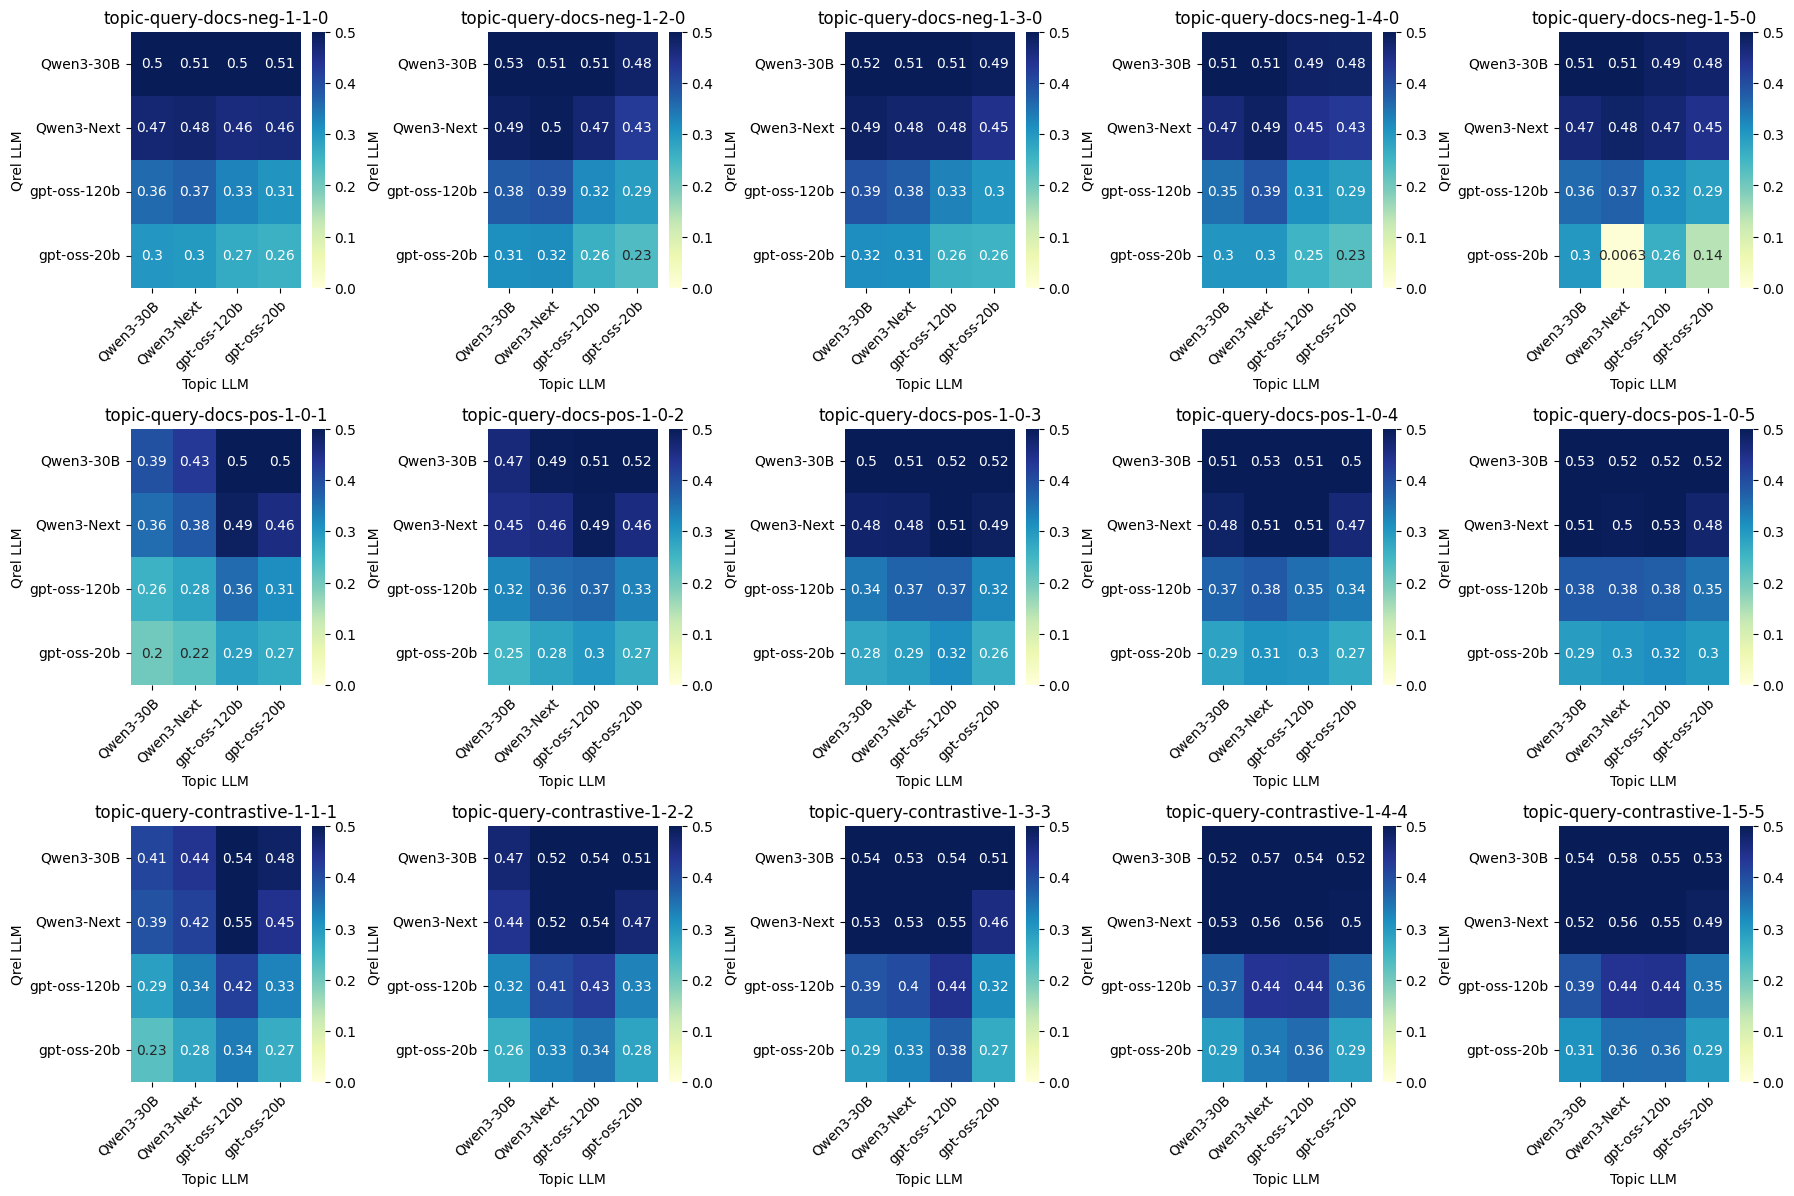

In [37]:
df = load_results("robust")
full_plot(df)

/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/2722070942.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(df.pivot_table(index="model", columns="topics_model", values="kappa", aggfunc="mean"),annot=True, vmax=0.5, vmin=0.0,  cbar_kws={"label": "Cohen's Kappa"})


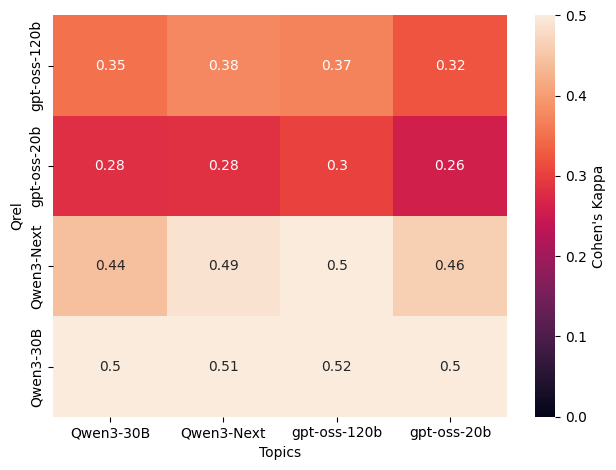

In [38]:
sns.heatmap(df.pivot_table(index="model", columns="topics_model", values="kappa", aggfunc="mean"),annot=True, vmax=0.5, vmin=0.0,  cbar_kws={"label": "Cohen's Kappa"})
plt.xlabel("Topics")
plt.ylabel("Qrel")

plt.tight_layout()
plt.show()

In [39]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# formula = 'kappa ~ C(is_same_model) + C(is_same_family) + C(topics_prompt) + topics_ndocspos + topics_ndocsneg'
formula = "kappa ~ is_same_model + total_docs + C(model) + C(topics_model) + C(topics_prompt)"
model = smf.ols(formula, data=df).fit()

print(model.summary())
anova_table = sm.stats.anova_lm(model, typ=2)

# Eta Squared
anova_table['eta_sq'] = anova_table['sum_sq'] / sum(anova_table['sum_sq'])

print(anova_table)


                            OLS Regression Results                            
Dep. Variable:                  kappa   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     103.1
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           4.20e-85
Time:                        17:47:30   Log-Likelihood:                 436.03
No. Observations:                 256   AIC:                            -848.1
Df Residuals:                     244   BIC:                            -805.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

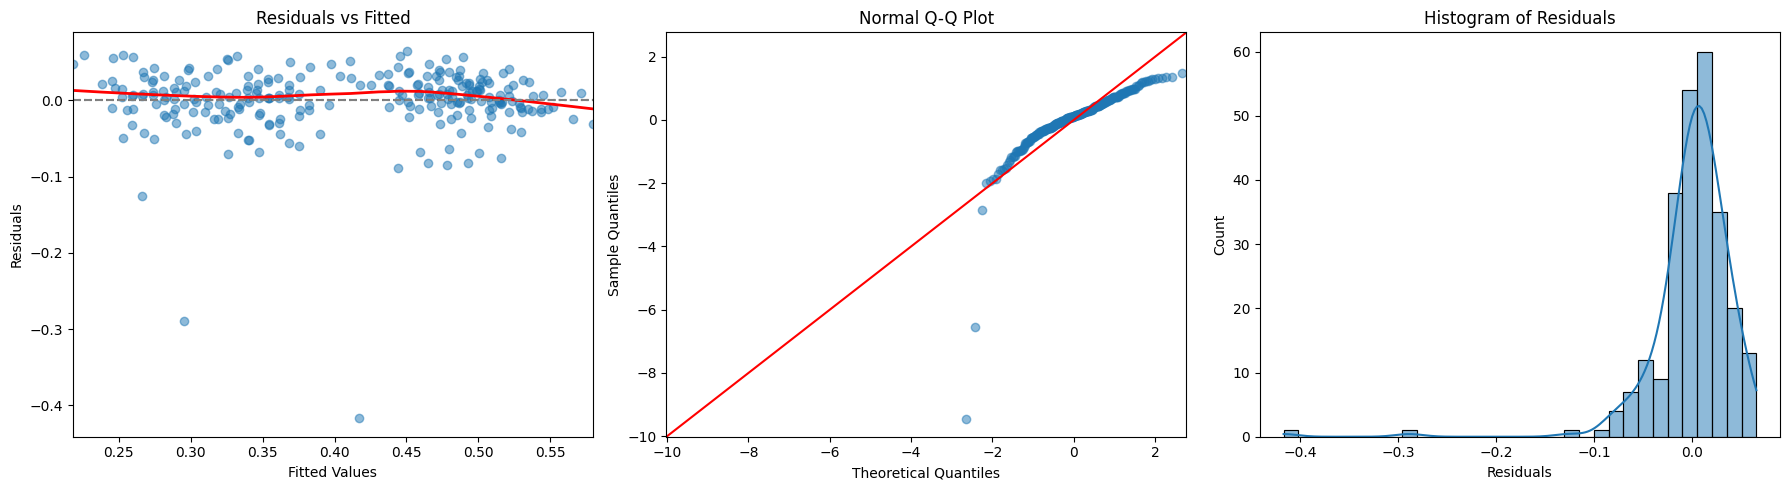

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

fitted_vals = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Residuals vs. Fitted (Checks for Homoscedasticity)
sns.residplot(x=fitted_vals, y=residuals, lowess=True, 
              scatter_kws={'alpha': 0.5}, 
              line_kws={'color': 'red', 'lw': 2}, ax=axes[0])
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].axhline(0, color='grey', linestyle='dashed')

# Plot B: Normal Q-Q Plot (Checks for Normality)
sm.qqplot(residuals, fit=True, line='45', ax=axes[1], alpha=0.5)
axes[1].set_title('Normal Q-Q Plot')

# Plot C: Histogram of Residuals (Visualizes Skew/Kurtosis)
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title('Histogram of Residuals')
axes[2].set_xlabel('Residuals')

plt.tight_layout()
plt.show()

# Combined

In [15]:
dfs = [load_results("robust"), load_results("dl20"), load_results("dl19")]

/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/1808734156.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata = metadata.fillna(0)
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/1808734156.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  metadata["topics_model"].f

In [16]:
df = pd.concat(dfs, ignore_index=True)

/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/2722070942.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(df.pivot_table(index="model", columns="topics_model", values="kappa", aggfunc="mean"),annot=True, vmax=0.5, vmin=0.0,  cbar_kws={"label": "Cohen's Kappa"})


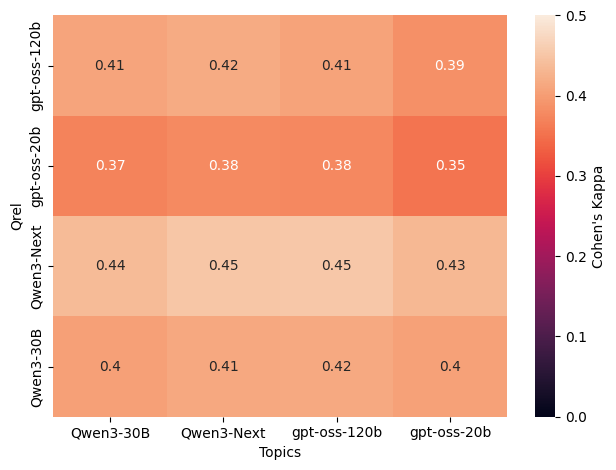

In [17]:
sns.heatmap(df.pivot_table(index="model", columns="topics_model", values="kappa", aggfunc="mean"),annot=True, vmax=0.5, vmin=0.0,  cbar_kws={"label": "Cohen's Kappa"})
plt.xlabel("Topics")
plt.ylabel("Qrel")

plt.tight_layout()
plt.show()

/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_81919/3710090299.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(df[df["topics_prompt"] == "topic-query-contrastive"].pivot_table(index="model", columns="topics_model", values="kappa", aggfunc="mean"),annot=True, vmax=0.5, vmin=0.0,  cbar_kws={"label": "Cohen's Kappa"})


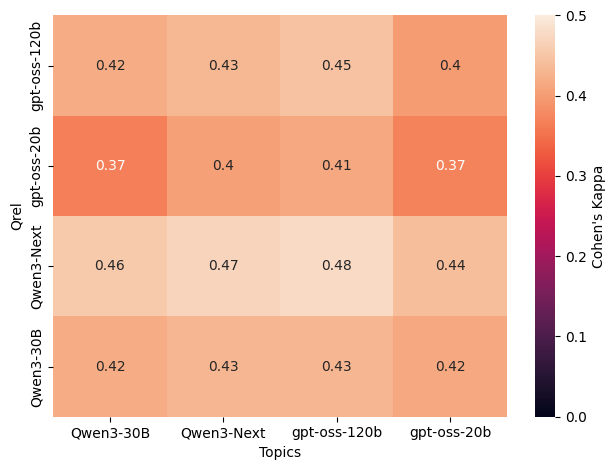

In [18]:
sns.heatmap(df[df["topics_prompt"] == "topic-query-contrastive"].pivot_table(index="model", columns="topics_model", values="kappa", aggfunc="mean"),annot=True, vmax=0.5, vmin=0.0,  cbar_kws={"label": "Cohen's Kappa"})
plt.xlabel("Topics")
plt.ylabel("Qrel")

plt.tight_layout()
plt.show()

In [20]:
df

,name,model,data,prompt,k,output,task,topics_date,topics_model,topics_data,...,topics_task,display_name,kappa,MAE,context,is_same_model,judge_family,topic_family,is_same_family,total_docs
0,2026-01-19_14:52:08,gpt-oss-120b,robust,-DNA-zero-shot,0,/workspaces/conf26-generating-topics/data/inte...,qrels,2026-01-08_21:06:51,Qwen3-Next,robust,...,topics,query-docs-pos,0.368198,0.5611657065401559,3.0,0,gpt,Qwen3,0,3.0
1,2026-01-19_12:50:11,Qwen3-30B,robust,-DNA-zero-shot,0,/workspaces/conf26-generating-topics/data/inte...,qrels,2026-01-08_21:01:34,Qwen3-Next,robust,...,topics,query-docs-pos,0.494824,0.4581497797356828,2.0,0,Qwen3,Qwen3,1,2.0
2,2026-01-18_16:52:53,Qwen3-Next,robust,-DNA-zero-shot,0,/workspaces/conf26-generating-topics/data/inte...,qrels,2026-01-10_18:49:34,gpt-oss-20b,robust,...,topics,query-docs-pos,0.488919,0.4545145960624576,3.0,0,Qwen3,gpt,0,3.0
3,2025-12-15_15:11:26,gpt-oss-20b,robust,-DNA-zero-shot,0,/workspaces/conf26-generating-topics/data/inte...,qrels,2025-12-01_19:47:05,gpt-oss-20b,robust,...,topics,query-contrastive,0.286922,0.6418063633253507,4.0,1,gpt,gpt,1,8.0
4,2025-12-26_21:19:03,gpt-oss-20b,robust,-DNA-zero-shot,0,/workspaces/conf26-generating-topics/data/inte...,qrels,2025-11-25_14:45:17,Qwen3-30B,robust,...,topics,query-contrastive,0.262492,0.6760420196543545,2.0,0,gpt,Qwen3,0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,2026-01-06_16:00:58,Qwen3-30B,dl19,qrel_zeroshot_bing_topic,0,/workspaces/conf26-generating-topics/data/inte...,qrels,2025-12-21_14:11:03,gpt-oss-120b,dl19,...,topics,query-contrastive,0.384017,0.7370410367170627,1.0,0,Qwen3,gpt,0,2.0
764,2026-01-08_01:21:51,Qwen3-Next,dl19,qrel_zeroshot_bing_topic,0,/workspaces/conf26-generating-topics/data/inte...,qrels,2026-01-07_17:23:37,Qwen3-30B,dl19,...,topics,query-docs-neg,0.426021,0.5853131749460043,3.0,0,Qwen3,Qwen3,1,3.0
765,2026-01-07_13:59:23,gpt-oss-20b,dl19,qrel_zeroshot_bing_topic,0,/workspaces/conf26-generating-topics/data/inte...,qrels,2025-12-21_14:00:13,gpt-oss-120b,dl19,...,topics,query,0.366891,0.5840172786177106,1.0,0,gpt,gpt,1,0.0
766,2026-01-08_18:09:08,gpt-oss-120b,dl19,qrel_zeroshot_bing_topic,0,/workspaces/conf26-generating-topics/data/inte...,qrels,2026-01-07_17:43:34,Qwen3-Next,dl19,...,topics,query-docs-pos,0.456262,0.5295896328293737,3.0,0,gpt,Qwen3,0,3.0


In [21]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# formula = 'kappa ~ C(is_same_model) + C(is_same_family) + C(topics_prompt) + topics_ndocspos + topics_ndocsneg'
# formula = "kappa ~ is_same_model + total_docs + C(model) + C(topics_model) + C(topics_prompt)"
formula = "kappa ~ is_same_model + total_docs + C(model) + C(topics_model) + C(topics_prompt) * C(data)"
# formula = "kappa ~ total_docs + C(model) + C(topics_model) + C(topics_prompt) * C(data)"
model = smf.ols(formula, data=df).fit()

print(model.summary())
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                            OLS Regression Results                            
Dep. Variable:                  kappa   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     11.30
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.22e-30
Time:                        12:11:30   Log-Likelihood:                 1080.6
No. Observations:                 768   AIC:                            -2121.
Df Residuals:                     748   BIC:                            -2028.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [22]:
import pandas as pd

# Create a frequency matrix of Prompts vs. Datasets
crosstab_result = pd.crosstab(df['topics_prompt'], df['data'])
print(crosstab_result)

data                     dl19  dl20  robust
topics_prompt                              
topic-query                16    16      16
topic-query-docs-neg       80    80      80
topic-query-docs-pos       80    80      80
topic-query-contrastive    80    80      80
